In [1]:
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns

In [2]:
dict_sales_data = {
    'month': [
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ],
    'sales': [
        2000, 2200, 2300, 2500, 2600, 2700,
        2800, 2900, 3000, 3100, 3200, 3300
    ]
}

In [3]:
sales_data = pd.DataFrame.from_dict(dict_sales_data)

In [4]:
sales_data

,month,sales
0,January,2000
1,February,2200
2,March,2300
3,April,2500
4,May,2600
5,June,2700
6,July,2800
7,August,2900
8,September,3000
9,October,3100


In [5]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   month   12 non-null     str  
 1   sales   12 non-null     int64
dtypes: int64(1), str(1)
memory usage: 324.0 bytes


In [6]:
sales_data.describe()

,sales
count,12.000000
mean,2716.666667
std,410.838020
min,2000.000000
25%,2450.000000
50%,2750.000000
75%,3025.000000
max,3300.000000


In [20]:
sales_data['month'] = sales_data['month'].map({
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
})

In [22]:
sales_data

,month,sales
0,1,2000
1,2,2200
2,3,2300
3,4,2500
4,5,2600
5,6,2700
6,7,2800
7,8,2900
8,9,3000
9,10,3100


<Axes: xlabel='month', ylabel='sales'>

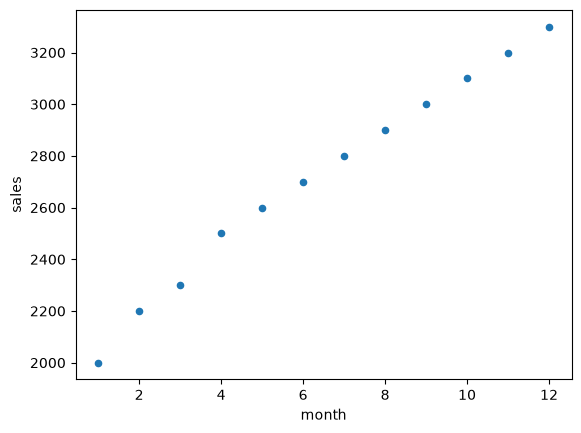

In [26]:
sales_data.plot.scatter(x='month', y='sales')

## The data shows a linear upward trend, with a constant increase of 100 units between consecutive months.

In [27]:
sales_data.mean()

month       6.500000
sales    2716.666667
dtype: float64

In [29]:
sales_data['sales'].median()

np.float64(2750.0)

In [30]:
sales_data['month'].corr(sales_data['sales'])

np.float64(0.9942143462051067)

In [31]:
import seaborn as sns

<Axes: >

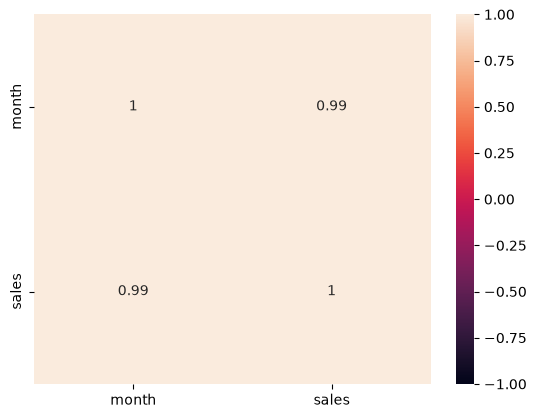

In [ ]:
sns.heatmap(sales_data.corr(), vmin=-1, vmax=1, annot=True)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [47]:
X = sales_data[['month']]
y = sales_data['sales']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [49]:
len(X_test)

4

In [51]:
# Train model with LinearRegression
model = LinearRegression().fit(X_train, y_train)

In [53]:
y_pred = model.predict(X_test)

In [54]:
model.coef_

array([114.16666667])

In [55]:
model.intercept_

np.float64(1963.3333333333333)

In [56]:
model.score(X_train, y_train)

0.990709949854843

In [57]:
model.score(X_test, y_test)

0.9631440781440782

In [58]:
r2_score(y_test, y_pred)

0.9631440781440782

In [59]:
# MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

36.66666666666663

In [60]:
december = pd.DataFrame({'month': [12]})
december_pred = model.predict(december)


In [62]:
december_pred[0]

np.float64(3333.3333333333335)

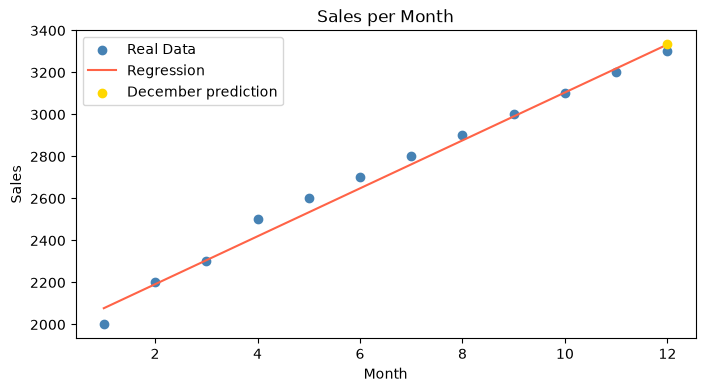

In [63]:
# Scatter 
plt.figure(figsize=(8, 4))
plt.scatter(sales_data['month'], sales_data['sales'], color='steelblue', label='Real Data')
plt.plot(sales_data['month'], model.predict(X), color='tomato', label='Regression')
plt.scatter([12], december_pred, color='gold', zorder=5, label='December prediction')
plt.title('Sales per Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.show()